In [5]:
import pandas as pd

#Importing the datasets

lipo_df_test = pd.read_csv('../lipo_splits/lipo_test.csv')
lipo_df_train = pd.read_csv('../lipo_splits/lipo_train.csv')
lipo_df_val = pd.read_csv('../lipo_splits/lipo_val.csv')

qm7_df_test = pd.read_csv('../qm7_splits/qm7_test.csv')
qm7_df_train = pd.read_csv('../qm7_splits/qm7_train.csv')
qm7_df_val = pd.read_csv('../qm7_splits/qm7_val.csv')




dr_df_test = pd.read_csv('../data/data_splits/data/dr_splits/dr_test.csv')
dr_df_train = pd.read_csv('../data/data_splits/data/dr_splits/dr_train.csv')
dr_df_val = pd.read_csv('../data/data_splits/data/dr_splits/dr_val.csv')



sd_test = pd.read_csv('../data/data_splits/data/sd_splits/sd_test.csv')
sd_train = pd.read_csv('../data/data_splits/data/sd_splits/sd_train.csv')
sd_val = pd.read_csv('../data/data_splits/data/sd_splits/sd_val.csv')



In [6]:
import pandas as pd
lipo = pd.concat([lipo_df_test['exp'], lipo_df_train['exp'], lipo_df_val['exp']])
qm7 = pd.concat([qm7_df_test['u0_atom'], qm7_df_train['u0_atom'], qm7_df_val['u0_atom']])
dr = pd.concat([dr_df_test['DR'], dr_df_train['DR'], dr_df_val['DR']])
sd = pd.concat([sd_test['SD'], sd_train['SD'], sd_val['SD']])

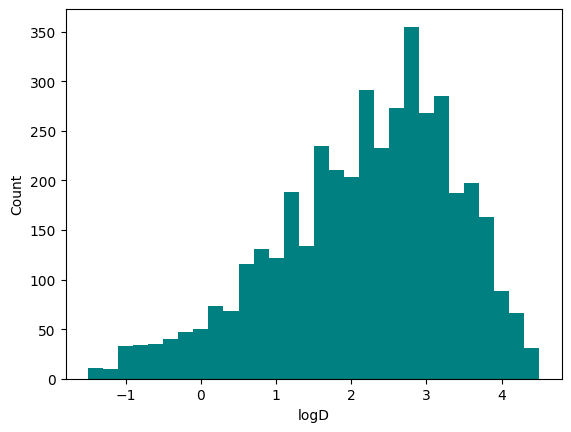

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.hist(lipo, bins=30,color = 'teal')
plt.xlabel('logD')
plt.ylabel('Count')
plt.title('Lipophilicity (logD) Distribution - Lipophilicity dataset')
plt.show()


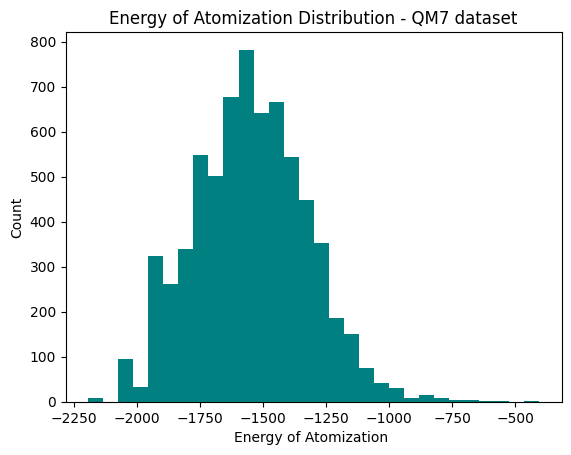

In [35]:
plt.hist(qm7, bins=30,color = "teal")
plt.xlabel('Energy of Atomization ')
plt.ylabel('Count')
plt.title('Energy of Atomization Distribution - QM7 dataset')
plt.show()

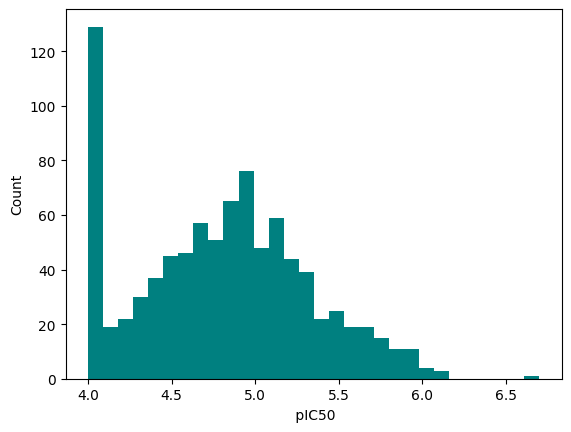

In [36]:
plt.hist(dr, bins=30,color = "teal")
plt.xlabel(' pIC50')
plt.ylabel('Count')
#plt.title('pIC50 Distribution - MF-PCBA (DR) dataset')
plt.show()

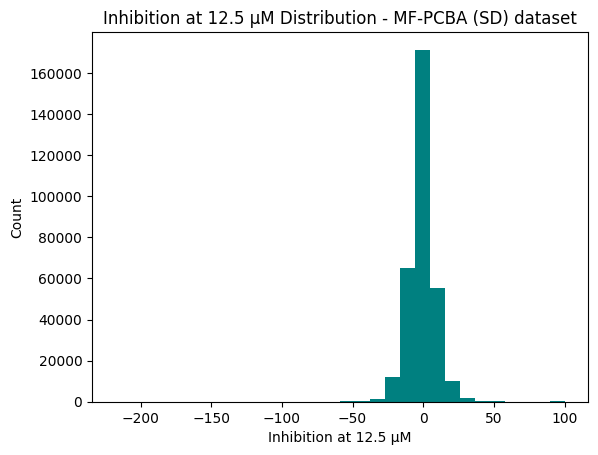

In [38]:
plt.hist(sd, bins=30,color = 'teal')
plt.xlabel('Inhibition at 12.5 µM')
plt.ylabel('Count')
plt.title('Inhibition at 12.5 µM Distribution - MF-PCBA (SD) dataset')
plt.show()

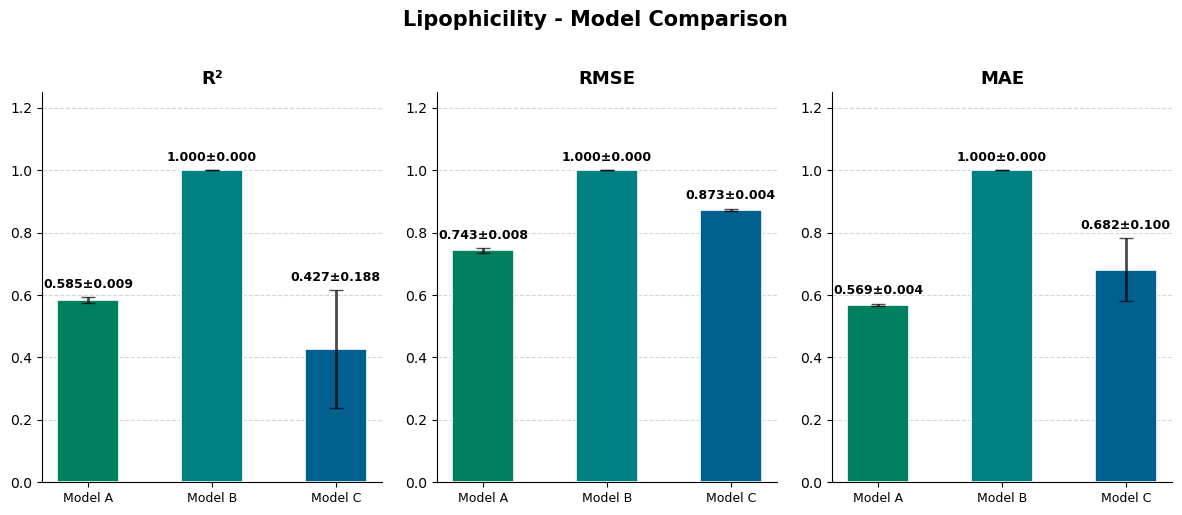

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data ---
metrics = ['R²', 'RMSE', 'MAE']
model_a = [0.585, 0.743, 0.569]
model_a_std = [0.009, 0.008, 0.004]  # Add your std values here

model_b = [1, 1, 1]
model_b_std = [0.0, 0.0, 0.0]  # Add your std values here

model_c = [0.427, 0.873, 0.682]
model_c_std = [0.188, 0.004, 0.100]  # Add your std values here

models = {
    'Model A': model_a,
    'Model B': model_b,
    'Model C': model_c,
}

stds = {
    'Model A': model_a_std,
    'Model B': model_b_std,
    'Model C': model_c_std,
}

colors = {
    'Model A': '#008060',
    'Model B': '#008080',
    'Model C': '#006090',
}

# --- Layout ---
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
fig.suptitle('Lipophicility - Model Comparison', fontsize=15, fontweight='bold', y=1.02)

for ax, metric, idx in zip(axes, metrics, range(3)):
    names = list(models.keys())
    values = [models[m][idx] for m in names]
    std_values = [stds[m][idx] for m in names]
    
    # Create bars with error bars
    bars = ax.bar(names, values, 
                   yerr=std_values,  # Add error bars
                   color=[colors[m] for m in names], 
                   width=0.5, 
                   edgecolor='white', 
                   linewidth=1.2,
                   capsize=5,  # Width of error bar caps
                   error_kw={'linewidth': 2, 'ecolor': 'black', 'alpha': 0.7})

    # Value labels on top of bars (adjusted for error bars)
    for bar, val, std in zip(bars, values, std_values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + std + max(values) * 0.02,
                f'{val:.3f}±{std:.3f}',  # Show mean ± std
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, max([v + s for v, s in zip(values, std_values)]) * 1.25)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('qm7_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
modelC_dr

,test/mae,test/rmse,test/r2
0,0.363520,0.470767,0.235412
1,0.353321,0.460623,0.268005
2,0.359050,0.464380,0.256016
3,0.363494,0.472906,0.228446
4,0.361233,0.464873,0.254438


In [32]:
import pandas as pd

#importing the values from the model
modelC_dr = pd.read_csv('../notebooks/dr_results_RF.csv')
modelC_qm7 = pd.read_csv('../notebooks/qm7_results_RF.csv')
modelC_lipo = pd.read_csv('../notebooks/lipo_results_RF.csv')

#R² values for all random forest datasets 
mean_r2_dr_C = modelC_dr['test/r2'].mean()
std_r2_dr_C = modelC_dr['test/r2'].std()

mean_r2_qm7_C = modelC_qm7['test/r2'].mean()
std_r2_qm7_C = modelC_qm7['test/r2'].std()

mean_r2_lipo_C = modelC_lipo['test/r2'].mean()
std_r2_lipo_C = modelC_lipo['test/r2'].std()

#MAE values for all random forest datasets
mean_mae_dr_C = modelC_dr['test/mae'].mean()
std_mae_dr_C = modelC_dr['test/mae'].std()
mean_mae_qm7_C = modelC_qm7['test/mae'].mean()
std_mae_qm7_C = modelC_qm7['test/mae'].std()
mean_mae_lipo_C = modelC_lipo['test/mae'].mean()
std_mae_lipo_C = modelC_lipo['test/mae'].std()  

#RMSE values for all random forest datasets
mean_rmse_dr_C = modelC_dr['test/rmse'].mean()      
std_rmse_dr_C = modelC_dr['test/rmse'].std()        
mean_rmse_qm7_C = modelC_qm7['test/rmse'].mean()    
std_rmse_qm7_C = modelC_qm7['test/rmse'].std()
mean_rmse_lipo_C = modelC_lipo['test/rmse'].mean()
std_rmse_lipo_C = modelC_lipo['test/rmse'].std()


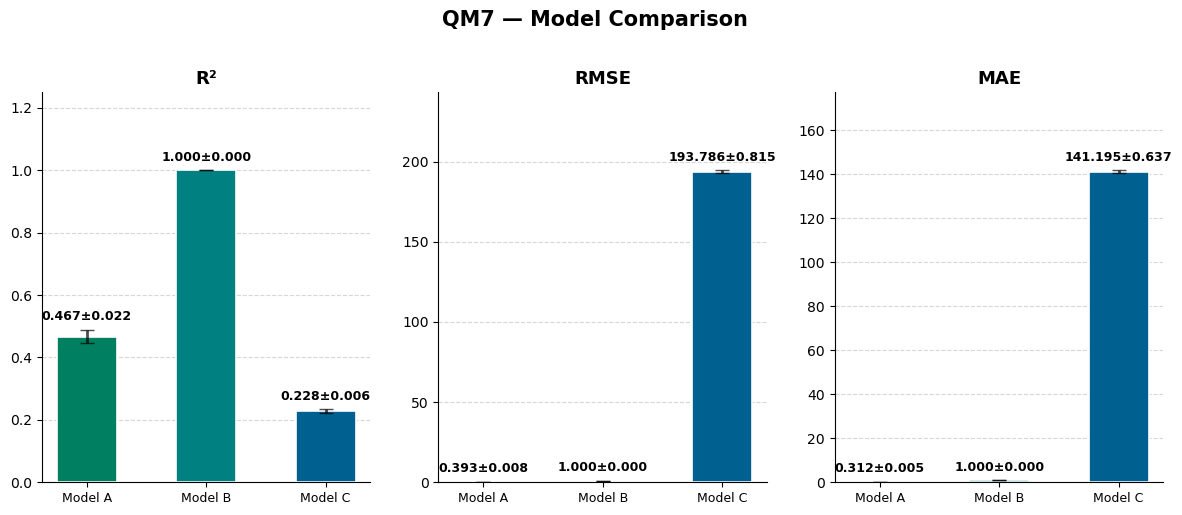

In [35]:
import matplotlib.pyplot as plt
import numpy as np



# --- Data ---
metrics = ['R²', 'RMSE', 'MAE']
model_a = [0.467, 0.393, 0.312]
model_a_std = [0.022, 0.008, 0.005]  # Add your std values here

model_b = [1, 1, 1]
model_b_std = [0.0, 0.0, 0.0]  # Add your std values here

model_c = [mean_r2_qm7_C, mean_rmse_qm7_C, mean_mae_qm7_C]
model_c_std = [std_r2_qm7_C, std_rmse_qm7_C, std_mae_qm7_C]  # Add your std values here

models = {
    'Model A': model_a,
    'Model B': model_b,
    'Model C': model_c,
}

stds = {
    'Model A': model_a_std,
    'Model B': model_b_std,
    'Model C': model_c_std,
}

colors = {
    'Model A': '#008060',
    'Model B': '#008080',
    'Model C': '#006090',
}

# --- Layout ---
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
fig.suptitle('QM7 — Model Comparison', fontsize=15, fontweight='bold', y=1.02)

for ax, metric, idx in zip(axes, metrics, range(3)):
    names = list(models.keys())
    values = [models[m][idx] for m in names]
    std_values = [stds[m][idx] for m in names]
    
    # Create bars with error bars
    bars = ax.bar(names, values, 
                   yerr=std_values,  # Add error bars
                   color=[colors[m] for m in names], 
                   width=0.5, 
                   edgecolor='white', 
                   linewidth=1.2,
                   capsize=5,  # Width of error bar caps
                   error_kw={'linewidth': 2, 'ecolor': 'black', 'alpha': 0.7})

    # Value labels on top of bars (adjusted for error bars)
    for bar, val, std in zip(bars, values, std_values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + std + max(values) * 0.02,
                f'{val:.3f}±{std:.3f}',  # Show mean ± std
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, max([v + s for v, s in zip(values, std_values)]) * 1.25)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('qm7_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

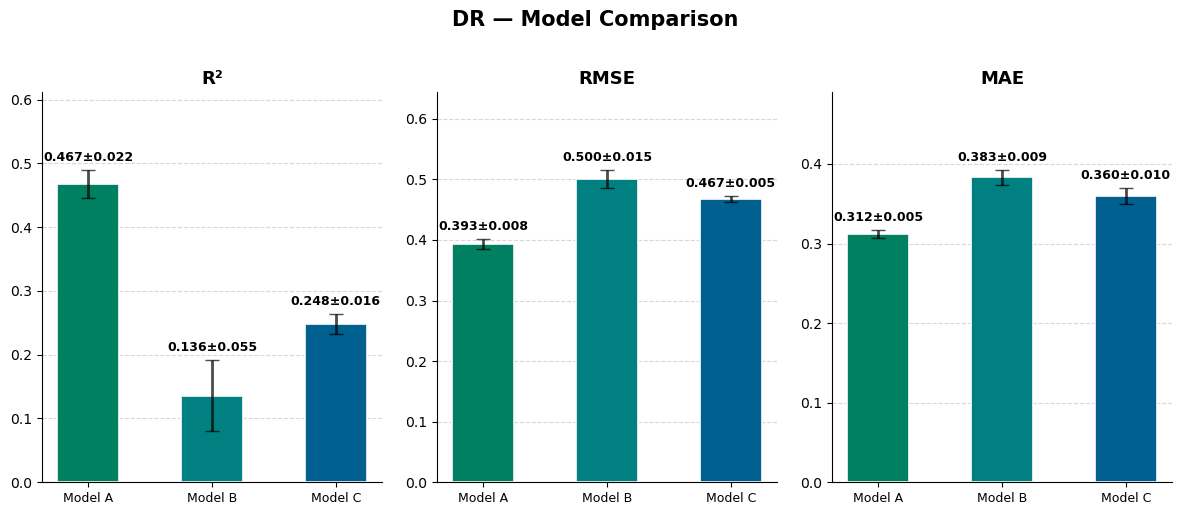

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data ---
metrics = ['R²', 'RMSE', 'MAE']

model_a = [0.467, 0.393, 0.312]
model_a_std = [0.022, 0.008, 0.005]  

model_b = [0.136, 0.500, 0.383]
model_b_std = [0.055, 0.015, 0.009]  

model_c = [mean_r2_dr_C, mean_rmse_dr_C, mean_mae_dr_C]
model_c_std = [std_r2_dr_C, std_rmse_dr_C, std_mae_dr_C]  

models = {
    'Model A': model_a,
    'Model B': model_b,
    'Model C': model_c,
}

stds = {
    'Model A': model_a_std,
    'Model B': model_b_std,
    'Model C': model_c_std,
}

colors = {
    'Model A': '#008060',
    'Model B': '#008080',
    'Model C': '#006090',
}

# --- Layout ---
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
fig.suptitle('DR — Model Comparison', fontsize=15, fontweight='bold', y=1.02)

for ax, metric, idx in zip(axes, metrics, range(3)):
    names = list(models.keys())
    values = [models[m][idx] for m in names]
    std_values = [stds[m][idx] for m in names]
    
    # Create bars with error bars
    bars = ax.bar(names, values, 
                   yerr=std_values,  # Add error bars
                   color=[colors[m] for m in names], 
                   width=0.5, 
                   edgecolor='white', 
                   linewidth=1.2,
                   capsize=5,  # Width of error bar caps
                   error_kw={'linewidth': 2, 'ecolor': 'black', 'alpha': 0.7})

    # Value labels on top of bars (adjusted for error bars)
    for bar, val, std in zip(bars, values, std_values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + std + max(values) * 0.02,
                f'{val:.3f}±{std:.3f}',  # Show mean ± std
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, max([v + s for v, s in zip(values, std_values)]) * 1.25)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('qm7_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

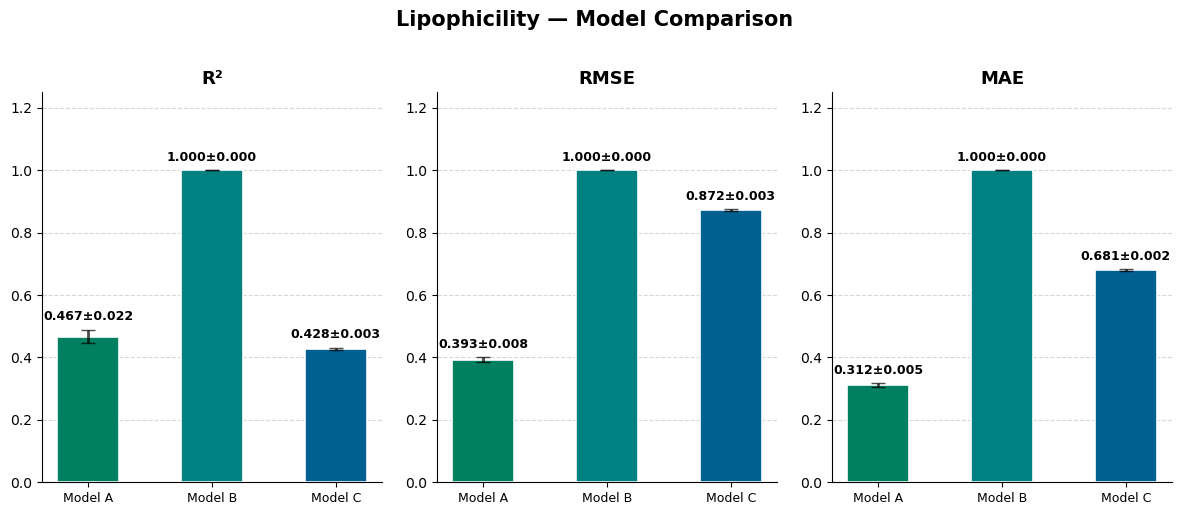

In [36]:
import matplotlib.pyplot as plt
import numpy as np



# --- Data ---
metrics = ['R²', 'RMSE', 'MAE']
model_a = [0.467, 0.393, 0.312]
model_a_std = [0.022, 0.008, 0.005]  
model_b = [1, 1, 1]
model_b_std = [0.0, 0.0, 0.0]  

model_c = [mean_r2_lipo_C, mean_rmse_lipo_C, mean_mae_lipo_C]
model_c_std = [std_r2_lipo_C, std_rmse_lipo_C, std_mae_lipo_C]  

models = {
    'Model A': model_a,
    'Model B': model_b,
    'Model C': model_c,
}

stds = {
    'Model A': model_a_std,
    'Model B': model_b_std,
    'Model C': model_c_std,
}

colors = {
    'Model A': '#008060',
    'Model B': '#008080',
    'Model C': '#006090',
}

# --- Layout ---
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
fig.suptitle('Lipophicility — Model Comparison', fontsize=15, fontweight='bold', y=1.02)

for ax, metric, idx in zip(axes, metrics, range(3)):
    names = list(models.keys())
    values = [models[m][idx] for m in names]
    std_values = [stds[m][idx] for m in names]
    
    # Create bars with error bars
    bars = ax.bar(names, values, 
                   yerr=std_values,  # Add error bars
                   color=[colors[m] for m in names], 
                   width=0.5, 
                   edgecolor='white', 
                   linewidth=1.2,
                   capsize=5,  # Width of error bar caps
                   error_kw={'linewidth': 2, 'ecolor': 'black', 'alpha': 0.7})

    # Value labels on top of bars (adjusted for error bars)
    for bar, val, std in zip(bars, values, std_values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + std + max(values) * 0.02,
                f'{val:.3f}±{std:.3f}',  # Show mean ± std
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, max([v + s for v, s in zip(values, std_values)]) * 1.25)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('qm7_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()